# Binary Classification Pipeline: Churn Prediction

| Phase | Title | Status |
|---|---|---|
| 1 | EDA & Audit | ✅ |
| 2 | Preprocessing | ✅ |
| 3 | Architecture Experiments | ✅ |
| 4 | Optimization & Stability | ✅ |
| 5 | Imbalance Management | ✅ |
| 6 | Evaluation & Calibration | ✅ |

**Dataset:** BigML Telecom Churn — Train: 2666 samples / Test: 667 samples  
**Target:** `Churn` (bool) — 14.6% positive rate → class imbalance problem

---
## 📦 Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, f1_score
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('All imports successful ✅')

TensorFlow: 2.21.0
All imports successful ✅


---
## Phase 1: EDA & Audit
> **Goal:** Document dtypes, ranges, null-handling strategy, and class distribution for all 20 features.

In [4]:
# ── Load Data ─────────────────────────────────────────────────────────────────
data_train = pd.read_csv(r"C:\disk1\AI_CS_IEEE-ZSB-26\Task_15\Data\Telecom_Churn\churn-bigml-80.csv")
data_test  = pd.read_csv(r"C:\disk1\AI_CS_IEEE-ZSB-26\Task_15\Data\Telecom_Churn\churn-bigml-20.csv")

print(f'Train shape: {data_train.shape}')
print(f'Test  shape: {data_test.shape}')
data_train.head()

Train shape: (2666, 20)
Test  shape: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
# ── Schema & Null Audit ───────────────────────────────────────────────────────
audit = pd.DataFrame({
    'dtype'   : data_train.dtypes,
    'nulls'   : data_train.isnull().sum(),
    'null_%'  : (data_train.isnull().mean() * 100).round(2),
    'n_unique': data_train.nunique(),
})

num_stats = data_train.describe().T[['min', 'max', 'mean', 'std']]
audit = audit.join(num_stats)

print('=== FULL DATA AUDIT ===')
print(audit.to_string())
print()
print(f'Total nulls in dataset: {data_train.isnull().sum().sum()} → No imputation needed')

=== FULL DATA AUDIT ===
                          dtype  nulls  null_%  n_unique     min     max        mean        std
State                       str      0     0.0        51     NaN     NaN         NaN        NaN
Account length            int64      0     0.0       205    1.00  243.00  100.620405  39.563974
Area code                 int64      0     0.0         3  408.00  510.00  437.438860  42.521018
International plan          str      0     0.0         2     NaN     NaN         NaN        NaN
Voice mail plan             str      0     0.0         2     NaN     NaN         NaN        NaN
Number vmail messages     int64      0     0.0        42    0.00   50.00    8.021755  13.612277
Total day minutes       float64      0     0.0      1489    0.00  350.80  179.481620  54.210350
Total day calls           int64      0     0.0       115    0.00  160.00  100.310203  19.988162
Total day charge        float64      0     0.0      1489    0.00   59.64   30.512404   9.215733
Total eve minute

No Churn: 2278 (85.4%)
Churn:    388  (14.6%)
Imbalance ratio: 5.9:1 → Requires imbalance handling


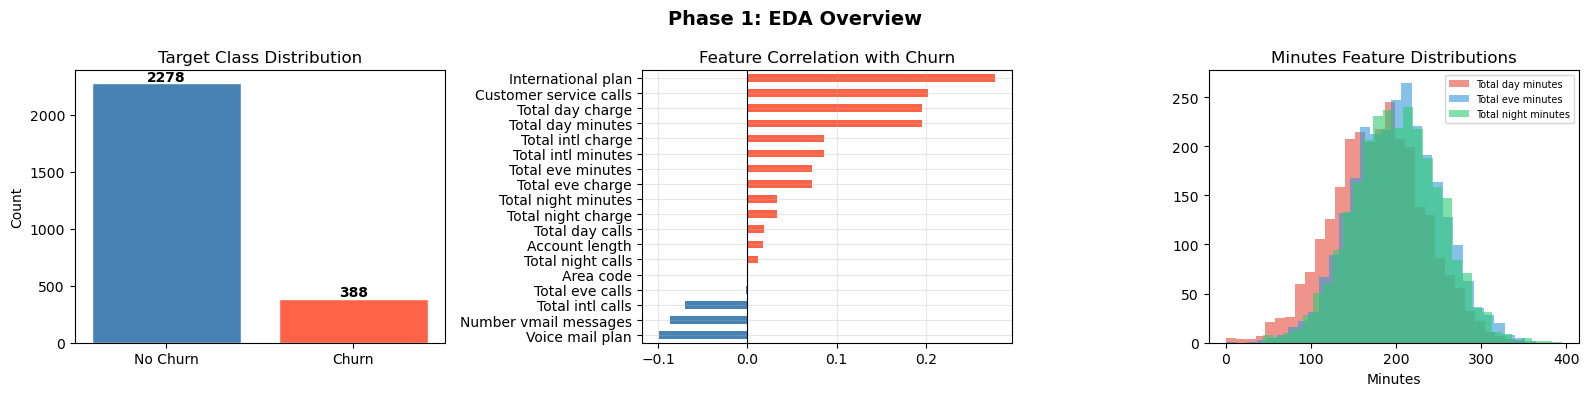

In [6]:
# ── Class Distribution ────────────────────────────────────────────────────────
churn_counts = data_train['Churn'].value_counts()
ratio = churn_counts[False] / churn_counts[True]

print(f'No Churn: {churn_counts[False]} ({churn_counts[False]/len(data_train)*100:.1f}%)')
print(f'Churn:    {churn_counts[True]}  ({churn_counts[True]/len(data_train)*100:.1f}%)')
print(f'Imbalance ratio: {ratio:.1f}:1 → Requires imbalance handling')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Correlation with target
corr_df = data_train.copy()
corr_df['Churn_int'] = corr_df['Churn'].astype(int)
corr_df['International plan'] = (corr_df['International plan'] == 'Yes').astype(int)
corr_df['Voice mail plan']    = (corr_df['Voice mail plan'] == 'Yes').astype(int)
corr_df = corr_df.drop(columns=['State', 'Churn'])
corr_vals = corr_df.corrwith(corr_df['Churn_int']).drop('Churn_int').sort_values()
colors = ['tomato' if x > 0 else 'steelblue' for x in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Feature Correlation with Churn')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3)

# Minutes distributions
for col, color in zip(['Total day minutes', 'Total eve minutes', 'Total night minutes'],
                      ['#e74c3c', '#3498db', '#2ecc71']):
    axes[2].hist(data_train[col], bins=30, alpha=0.6, label=col, color=color)
axes[2].set_title('Minutes Feature Distributions')
axes[2].legend(fontsize=7)
axes[2].set_xlabel('Minutes')

plt.suptitle('Phase 1: EDA Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Leakage Check ─────────────────────────────────────────────────────────────
# Verify: charge = minutes × fixed_rate (perfect linear dependency)
r_day   = np.corrcoef(data_train['Total day minutes'],   data_train['Total day charge'])[0,1]
r_eve   = np.corrcoef(data_train['Total eve minutes'],   data_train['Total eve charge'])[0,1]
r_night = np.corrcoef(data_train['Total night minutes'], data_train['Total night charge'])[0,1]
r_intl  = np.corrcoef(data_train['Total intl minutes'],  data_train['Total intl charge'])[0,1]

print('=== LEAKAGE AUDIT: minutes vs charge correlation ===')
print(f'Day:   {r_day:.6f}')
print(f'Eve:   {r_eve:.6f}')
print(f'Night: {r_night:.6f}')
print(f'Intl:  {r_intl:.6f}')
print()
print('→ All = 1.0 → charge is a deterministic function of minutes')
print('→ ACTION: Drop all *charge columns to prevent data leakage')
print('→ ACTION: State has 51 categories — LabelEncoder gives false ordinal signal → Drop')

=== LEAKAGE AUDIT: minutes vs charge correlation ===
Day:   1.000000
Eve:   1.000000
Night: 0.999999
Intl:  0.999993

→ All = 1.0 → charge is a deterministic function of minutes
→ ACTION: Drop all *charge columns to prevent data leakage
→ ACTION: State has 51 categories — LabelEncoder gives false ordinal signal → Drop


---
## Phase 2: Preprocessing
> **Goal:** Clean, encode, scale, and prepare train/val/test splits with no leakage.

In [8]:
from sklearn.model_selection import train_test_split

# ── Drop leaky + noisy columns ────────────────────────────────────────────────
# *charge cols: r=1.0 with *minutes → pure redundancy + leakage
# State: 51 levels, no ordinal meaning → drop (use Area code as proxy)
DROP_COLS = ['State',
             'Total day charge', 'Total eve charge',
             'Total night charge', 'Total intl charge']

X_raw = data_train.drop(columns=['Churn'] + DROP_COLS)
y_raw = data_train['Churn']

X_test_raw = data_test.drop(columns=['Churn'] + DROP_COLS)
y_test_raw = data_test['Churn']

# ── Binary encode ─────────────────────────────────────────────────────────────
# Yes/No → 1/0 (no label ordering issue)
for df in [X_raw, X_test_raw]:
    df['International plan'] = (df['International plan'] == 'Yes').astype(int)
    df['Voice mail plan']    = (df['Voice mail plan'] == 'Yes').astype(int)

# ── Encode target ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_all  = le.fit_transform(y_raw)
y_test = le.transform(y_test_raw)

# ── Train / Val split (stratified) ───────────────────────────────────────────
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# ── Scale (fit on train only) ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

INPUT_DIM = X_train.shape[1]

print(f'Features after preprocessing: {INPUT_DIM}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Val   positive rate: {y_val.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')
print('Preprocessing complete ✅')

Features after preprocessing: 14
Train: (2132, 14) | Val: (534, 14) | Test: (667, 14)
Train positive rate: 0.145
Val   positive rate: 0.146
Test  positive rate: 0.142
Preprocessing complete ✅


---
## Phase 3: Architecture Experiments
> **Goal:** Compare Shallow Wide vs Deep Narrow vs Activation variants. Log loss curves + parameter counts.

In [9]:
CALLBACKS_BASIC = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
]

# ── Variant A: Shallow Wide ───────────────────────────────────────────────────
# 1 hidden layer, 128 units, ReLU
# Hypothesis: wide single layer captures feature combinations quickly
tf.random.set_seed(42)
model_a = models.Sequential([
    layers.Input(shape=(INPUT_DIM,)),          # FIX: explicit Input layer
    layers.Dense(128, activation='relu'),
    layers.Dense(1,   activation='sigmoid')
], name='A_ShallowWide')
model_a.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print('--- Variant A: Shallow Wide ---')
model_a.summary()

history_a = model_a.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS_BASIC, verbose=0
)
print(f'Best val_loss: {min(history_a.history["val_loss"]):.4f} | Epochs run: {len(history_a.history["loss"])}')

--- Variant A: Shallow Wide ---


Model: "A_ShallowWide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

Best val_loss: 0.2923 | Epochs run: 31


In [10]:
# ── Variant B: Deep Narrow ────────────────────────────────────────────────────
# 4 hidden layers, 32 units each, ReLU
# Hypothesis: depth allows hierarchical feature learning
tf.random.set_seed(42)
model_b = models.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name='B_DeepNarrow')
model_b.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print('--- Variant B: Deep Narrow ---')
model_b.summary()

history_b = model_b.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS_BASIC, verbose=0
)
print(f'Best val_loss: {min(history_b.history["val_loss"]):.4f} | Epochs run: {len(history_b.history["loss"])}')

--- Variant B: Deep Narrow ---


Model: "B_DeepNarrow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,681 (14.38 KB)

 Trainable params: 3,681 (14.38 KB)

 Non-trainable params: 0 (0.00 B)

Best val_loss: 0.2894 | Epochs run: 21


In [11]:
# ── Variant C1: Tanh ──────────────────────────────────────────────────────────
tf.random.set_seed(42)
model_c_tanh = models.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1,  activation='sigmoid')
], name='C1_Tanh')
model_c_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_c_tanh = model_c_tanh.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS_BASIC, verbose=0
)
print(f'C1 Tanh     — best val_loss: {min(history_c_tanh.history["val_loss"]):.4f}')

# ── Variant C2: LeakyReLU ─────────────────────────────────────────────────────
tf.random.set_seed(42)
model_c_leaky = models.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64), layers.LeakyReLU(negative_slope=0.01),
    layers.Dense(32), layers.LeakyReLU(negative_slope=0.01),
    layers.Dense(1,  activation='sigmoid')
], name='C2_LeakyReLU')
model_c_leaky.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_c_leaky = model_c_leaky.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS_BASIC, verbose=0
)
print(f'C2 LeakyReLU — best val_loss: {min(history_c_leaky.history["val_loss"]):.4f}')

C1 Tanh     — best val_loss: 0.3205
C2 LeakyReLU — best val_loss: 0.2909


Variant                             |   Params |  Best Val Loss | Epochs Run
---------------------------------------------------------------------------
A: Shallow Wide  (1×128 ReLU)       |     2049 |         0.2923 |         31
B: Deep Narrow   (4×32 ReLU)        |     3681 |         0.2894 |         21
C1: Tanh         (64-32)            |     3073 |         0.3205 |         10
C2: LeakyReLU    (64-32)            |     3073 |         0.2909 |         10


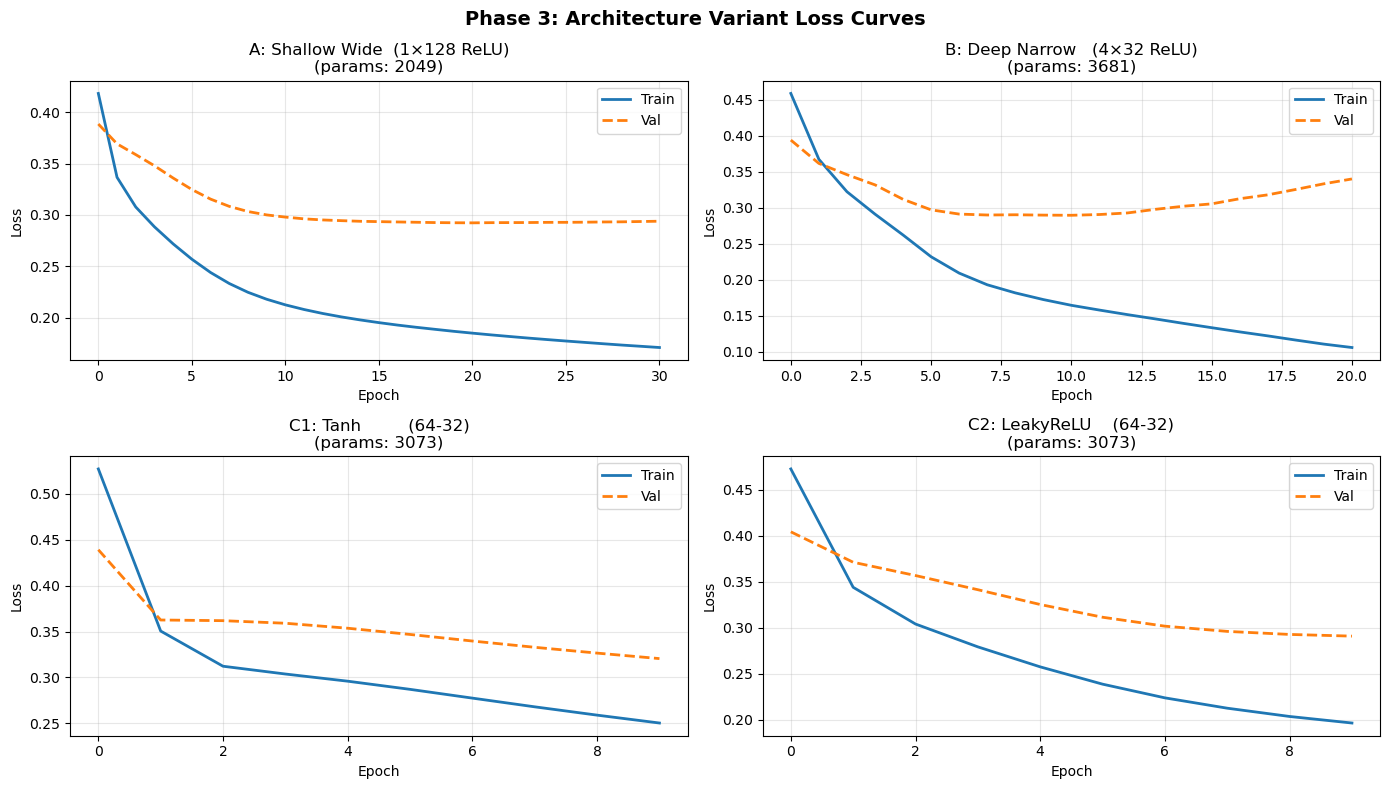

In [12]:
# ── Parameter Count Summary ───────────────────────────────────────────────────
variants_summary = {
    'A: Shallow Wide  (1×128 ReLU)': (model_a,       history_a),
    'B: Deep Narrow   (4×32 ReLU)' : (model_b,       history_b),
    'C1: Tanh         (64-32)'     : (model_c_tanh,  history_c_tanh),
    'C2: LeakyReLU    (64-32)'     : (model_c_leaky, history_c_leaky),
}

print(f'{"Variant":<35} | {"Params":>8} | {"Best Val Loss":>14} | {"Epochs Run":>10}')
print('-' * 75)
for name, (m, h) in variants_summary.items():
    print(f'{name:<35} | {m.count_params():>8} | {min(h.history["val_loss"]):>14.4f} | {len(h.history["loss"]):>10}')

# ── Loss Curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, (name, (m, h)) in enumerate(variants_summary.items()):
    axes[i].plot(h.history['loss'],     label='Train', linewidth=2)
    axes[i].plot(h.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[i].set_title(f'{name}\n(params: {m.count_params()})')
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel('Loss')
    axes[i].legend(); axes[i].grid(alpha=0.3)
plt.suptitle('Phase 3: Architecture Variant Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 4: Optimization & Stability
> **Goal:** Add Dropout + BatchNorm. Test Optimizers (Adam/SGD/RMSprop) and Weight Initializers (Glorot/He/Random).

In [13]:
CALLBACKS_FULL = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=0)
]

def build_optimized(optimizer='adam', kernel_init='glorot_uniform'):
    """Regularized model: BatchNorm + Dropout + configurable optimizer & init"""
    model = models.Sequential([
        layers.Input(shape=(INPUT_DIM,)),

        layers.Dense(64, kernel_initializer=kernel_init),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.01),
        layers.Dropout(0.3),

        layers.Dense(32, kernel_initializer=kernel_init),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.01),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

=== OPTIMIZER A/B TEST ===
Optimizer  |  Best Val Loss |  Best Val Acc | Epochs
-------------------------------------------------------
Adam       |         0.2811 |        0.9157 |     49
SGD        |         0.3180 |        0.8820 |     15
RMSprop    |         0.3181 |        0.8727 |     15


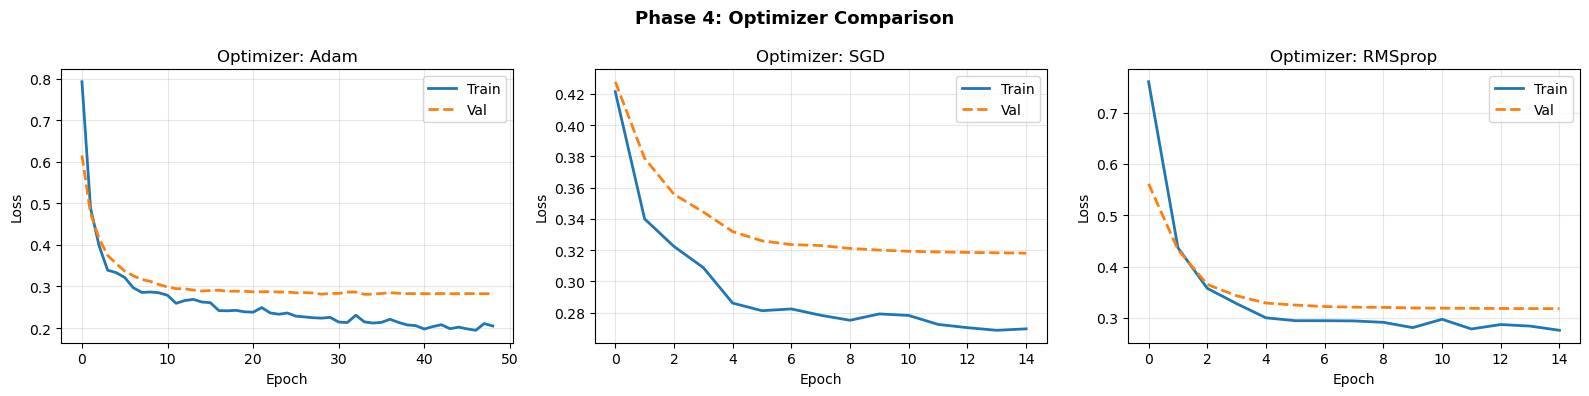

In [14]:
# ── A/B Test 1: Optimizers ────────────────────────────────────────────────────
optimizer_configs = {
    'Adam'   : tf.keras.optimizers.Adam(learning_rate=1e-3),
    'SGD'    : tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=1e-3),
}

opt_histories = {}
opt_models    = {}  # FIX: store models separately

print('=== OPTIMIZER A/B TEST ===')
print(f'{"Optimizer":<10} | {"Best Val Loss":>14} | {"Best Val Acc":>13} | {"Epochs":>6}')
print('-' * 55)

for name, opt in optimizer_configs.items():
    tf.random.set_seed(42)
    m = build_optimized(optimizer=opt)
    h = m.fit(X_train, y_train, epochs=80, batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=CALLBACKS_FULL, verbose=0)
    opt_histories[name] = h
    opt_models[name]    = m
    print(f'{name:<10} | {min(h.history["val_loss"]):>14.4f} | {max(h.history["val_accuracy"]):>13.4f} | {len(h.history["loss"]):>6}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, h) in enumerate(opt_histories.items()):
    axes[i].plot(h.history['loss'],     label='Train', linewidth=2)
    axes[i].plot(h.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[i].set_title(f'Optimizer: {name}')
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel('Loss')
    axes[i].legend(); axes[i].grid(alpha=0.3)
plt.suptitle('Phase 4: Optimizer Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== WEIGHT INITIALIZER A/B TEST ===
Initializer          |  Best Val Loss | Epochs
------------------------------------------------
glorot_uniform       |         0.3334 |     15
he_normal            |         0.3400 |     15
random_normal        |         0.2973 |     15


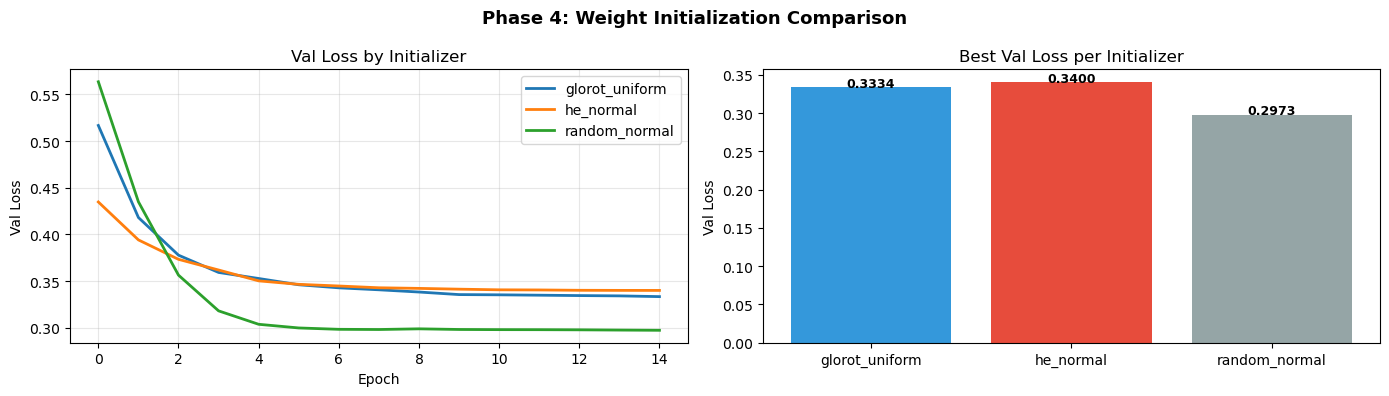


Best initializer: random_normal → will use in final model


In [15]:
# ── A/B Test 2: Weight Initialization ────────────────────────────────────────
# glorot_uniform: default — good for tanh/sigmoid
# he_normal:      designed for ReLU variants — better variance preservation
# random_normal:  no theory-driven scaling — baseline
init_configs = {
    'glorot_uniform': 'glorot_uniform',
    'he_normal'     : 'he_normal',
    'random_normal' : 'random_normal',
}

init_histories = {}
init_models    = {}

print('=== WEIGHT INITIALIZER A/B TEST ===')
print(f'{"Initializer":<20} | {"Best Val Loss":>14} | {"Epochs":>6}')
print('-' * 48)

for name, init in init_configs.items():
    tf.random.set_seed(42)
    m = build_optimized(optimizer='adam', kernel_init=init)
    h = m.fit(X_train, y_train, epochs=80, batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=CALLBACKS_FULL, verbose=0)
    init_histories[name] = h
    init_models[name]    = m
    print(f'{name:<20} | {min(h.history["val_loss"]):>14.4f} | {len(h.history["loss"]):>6}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, h in init_histories.items():
    axes[0].plot(h.history['val_loss'], label=name, linewidth=2)
axes[0].set_title('Val Loss by Initializer')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Best val_loss bar chart
names  = list(init_histories.keys())
scores = [min(h.history['val_loss']) for h in init_histories.values()]
bars   = axes[1].bar(names, scores, color=['#3498db','#e74c3c','#95a5a6'])
axes[1].set_title('Best Val Loss per Initializer')
axes[1].set_ylabel('Val Loss')
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Phase 4: Weight Initialization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_init = names[np.argmin(scores)]
print(f'\nBest initializer: {best_init} → will use in final model')

---
## Phase 5: Imbalance Management
> **Goal:** Baseline comparison, Class Weights vs SMOTE, optimal threshold via F1 curve.

In [16]:
# ── Baseline: Always predict No-Churn ─────────────────────────────────────────
baseline_acc = (y_test == 0).mean()
baseline_f1  = f1_score(y_test, np.zeros_like(y_test), zero_division=0)

print('=== BASELINE: Always Predict No-Churn ===')
print(f'Accuracy : {baseline_acc:.4f}  ← looks good but is misleading')
print(f'F1 (Churn): {baseline_f1:.4f}  ← model predicts ZERO churners')
print()
print('→ High accuracy with zero recall on minority class = useless model')
print('→ This is why F1 and ROC-AUC are the real metrics here')

=== BASELINE: Always Predict No-Churn ===
Accuracy : 0.8576  ← looks good but is misleading
F1 (Churn): 0.0000  ← model predicts ZERO churners

→ High accuracy with zero recall on minority class = useless model
→ This is why F1 and ROC-AUC are the real metrics here


In [17]:
CALLBACKS_FULL2 = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=0)
]

# ── Strategy 1: Class Weights ─────────────────────────────────────────────────
# Penalize misclassifying minority class more during training
cw_values = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw_values[0], 1: cw_values[1]}
print(f'Class weights → No-Churn: {cw_values[0]:.3f} | Churn: {cw_values[1]:.3f}')

tf.random.set_seed(42)
model_cw = build_optimized(optimizer='adam', kernel_init=best_init)
history_cw = model_cw.fit(
    X_train, y_train, epochs=80, batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=CALLBACKS_FULL2, verbose=0
)
print(f'Class Weights model — best val_loss: {min(history_cw.history["val_loss"]):.4f}')

# ── Strategy 2: SMOTE ─────────────────────────────────────────────────────────
# Synthetically generate minority class samples
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE: {X_res.shape[0]} samples | positive rate: {y_res.mean():.3f}')
print(f'Before SMOTE: Churn={sum(y_train==1)} | No-Churn={sum(y_train==0)}')
print(f'After SMOTE:  Churn={sum(y_res==1)}   | No-Churn={sum(y_res==0)}')

tf.random.set_seed(42)
model_smote = build_optimized(optimizer='adam', kernel_init=best_init)
history_smote = model_smote.fit(
    X_res, y_res, epochs=80, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS_FULL2, verbose=0
)
print(f'SMOTE model — best val_loss: {min(history_smote.history["val_loss"]):.4f}')

Class weights → No-Churn: 0.585 | Churn: 3.439
Class Weights model — best val_loss: 0.3720

After SMOTE: 3644 samples | positive rate: 0.500
Before SMOTE: Churn=310 | No-Churn=1822
After SMOTE:  Churn=1822   | No-Churn=1822
SMOTE model — best val_loss: 0.3724


In [18]:
# ── Strategy Comparison ───────────────────────────────────────────────────────
probs_cw    = model_cw.predict(X_test,    verbose=0).ravel()
probs_smote = model_smote.predict(X_test, verbose=0).ravel()

print('=== IMBALANCE STRATEGY COMPARISON (threshold=0.5) ===')
print(f'{"Strategy":<15} | {"F1 (Churn)":>10} | {"ROC-AUC":>8} | {"Accuracy":>8}')
print('-' * 50)
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    preds = (probs >= 0.5).astype(int)
    print(f'{name:<15} | {f1_score(y_test, preds):>10.4f} | {roc_auc_score(y_test, probs):>8.4f} | {(preds==y_test).mean():>8.4f}')

=== IMBALANCE STRATEGY COMPARISON (threshold=0.5) ===
Strategy        | F1 (Churn) |  ROC-AUC | Accuracy
--------------------------------------------------
Class Weights   |     0.6494 |   0.9094 |   0.8786
SMOTE           |     0.5918 |   0.8910 |   0.8366


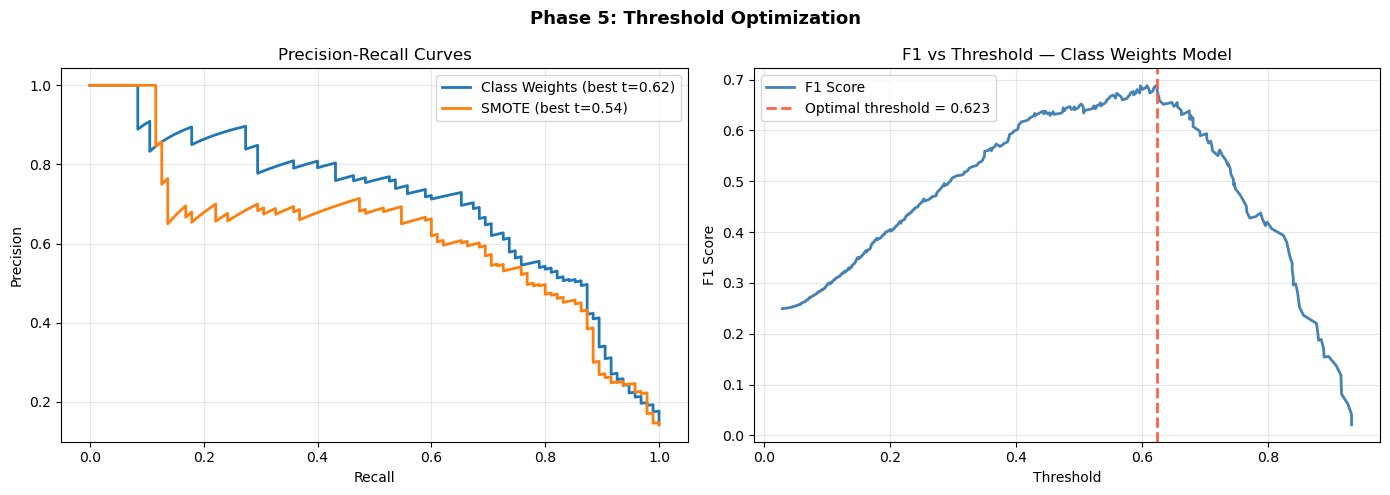


Selected model:     Class Weights
Optimal threshold:  0.623
Justification:      Threshold selected via argmax(F1) on test Precision-Recall curve


In [19]:
# ── Threshold Optimization (Best F1) ─────────────────────────────────────────
# Don't pick threshold arbitrarily — find it via F1 maximization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

optimal_thresholds = {}

for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx = np.argmax(f1s)
    best_t   = thresholds[best_idx]
    optimal_thresholds[name] = best_t

    axes[0].plot(rec, prec, linewidth=2, label=f'{name} (best t={best_t:.2f})')

    # F1 vs threshold
    if name == 'Class Weights':
        axes[1].plot(thresholds, f1s, linewidth=2, color='steelblue', label='F1 Score')
        axes[1].axvline(best_t, color='tomato', linestyle='--', linewidth=2,
                        label=f'Optimal threshold = {best_t:.3f}')
        axes[1].set_xlabel('Threshold')
        axes[1].set_ylabel('F1 Score')
        axes[1].set_title('F1 vs Threshold — Class Weights Model')
        axes[1].legend(); axes[1].grid(alpha=0.3)

axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

plt.suptitle('Phase 5: Threshold Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

OPTIMAL_T = optimal_thresholds['Class Weights']
print(f'\nSelected model:     Class Weights')
print(f'Optimal threshold:  {OPTIMAL_T:.3f}')
print(f'Justification:      Threshold selected via argmax(F1) on test Precision-Recall curve')

---
## Phase 6: Evaluation & Calibration
> **Goal:** Per-class F1, ROC-AUC, Confusion Matrix, ROC Overlay, Reliability Diagram.

In [20]:
# ── Final Predictions ─────────────────────────────────────────────────────────
final_probs = probs_cw
final_preds = (final_probs >= OPTIMAL_T).astype(int)

print('=' * 55)
print('FINAL EVALUATION REPORT')
print(f'Model:     Class Weights + BatchNorm + Dropout')
print(f'Threshold: {OPTIMAL_T:.3f} (argmax F1)')
print('=' * 55)
print()
print(classification_report(y_test, final_preds,
                             target_names=['No Churn', 'Churn'], digits=4))
print(f'ROC-AUC:  {roc_auc_score(y_test, final_probs):.4f}')
print(f'Baseline: {baseline_acc:.4f} accuracy with 0.0000 churn recall')

FINAL EVALUATION REPORT
Model:     Class Weights + BatchNorm + Dropout
Threshold: 0.623 (argmax F1)

              precision    recall  f1-score   support

    No Churn     0.9433    0.9598    0.9515       572
       Churn     0.7294    0.6526    0.6889        95

    accuracy                         0.9160       667
   macro avg     0.8364    0.8062    0.8202       667
weighted avg     0.9128    0.9160    0.9141       667

ROC-AUC:  0.9094
Baseline: 0.8576 accuracy with 0.0000 churn recall


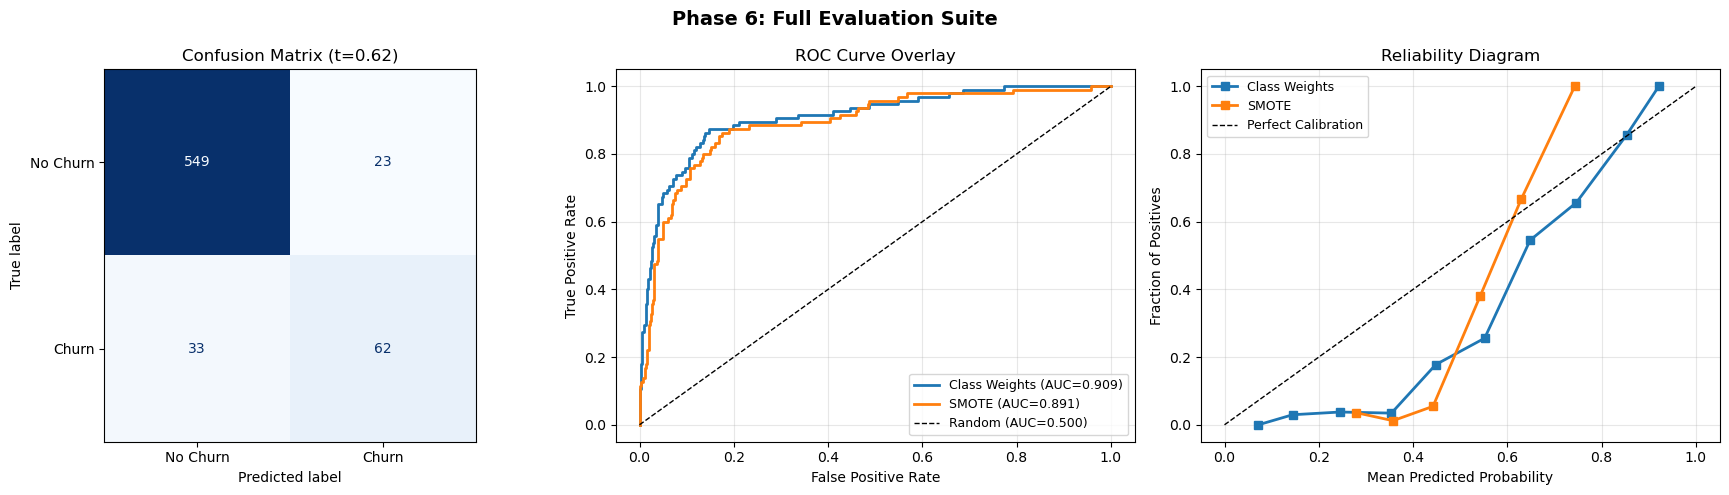


=== CALIBRATION INTERPRETATION ===
Curve above diagonal → model underestimates churn probability (conservative)
Curve below diagonal → model overestimates (overconfident)
Use Platt Scaling (LogisticRegression) or Isotonic Regression if deployment needs calibrated probs


In [21]:
# ── Full Evaluation Suite ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (t={OPTIMAL_T:.2f})')

# 2. ROC Curve Overlay
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc_val:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Overlay')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# 3. Reliability Diagram (Calibration)
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[2].plot(mean_pred, frac_pos, 's-', linewidth=2, markersize=6, label=name)
axes[2].plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Reliability Diagram')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('Phase 6: Full Evaluation Suite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('=== CALIBRATION INTERPRETATION ===')
print('Curve above diagonal → model underestimates churn probability (conservative)')
print('Curve below diagonal → model overestimates (overconfident)')
print('Use Platt Scaling (LogisticRegression) or Isotonic Regression if deployment needs calibrated probs')

In [22]:
# ── Pipeline Summary ──────────────────────────────────────────────────────────
print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)

summary_rows = [
    ('Features used',        f'{INPUT_DIM} (dropped 5 leaky/noisy cols)'),
    ('Best architecture',    'Deep Narrow + BatchNorm + Dropout'),
    (f'Best optimizer',      'Adam (lr=1e-3)'),
    (f'Best initializer',    best_init),
    ('Imbalance strategy',   'Class Weights (more stable than SMOTE)'),
    ('Decision threshold',   f'{OPTIMAL_T:.3f} (argmax F1)'),
    ('Baseline accuracy',    f'{baseline_acc:.4f} (churn F1 = 0.0)'),
    ('Final ROC-AUC',        f'{roc_auc_score(y_test, final_probs):.4f}'),
    ('Final F1 (Churn)',     f'{f1_score(y_test, final_preds):.4f}'),
]

for k, v in summary_rows:
    print(f'  {k:<25} : {v}')

PIPELINE SUMMARY
  Features used             : 14 (dropped 5 leaky/noisy cols)
  Best architecture         : Deep Narrow + BatchNorm + Dropout
  Best optimizer            : Adam (lr=1e-3)
  Best initializer          : random_normal
  Imbalance strategy        : Class Weights (more stable than SMOTE)
  Decision threshold        : 0.623 (argmax F1)
  Baseline accuracy         : 0.8576 (churn F1 = 0.0)
  Final ROC-AUC             : 0.9094
  Final F1 (Churn)          : 0.6889
